In [ ]:
from flask import Flask, render_template, request, redirect, session
import sqlite3

app = Flask(__name__)
app.secret_key = "secret123"

# ---------------- DATABASE ----------------
def init_db():
    conn = sqlite3.connect("database.db")
    cursor = conn.cursor()

    # Users table
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS users (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        username TEXT,
        password TEXT
    )
    ''')

    # Soil data table
    cursor.execute('''
    CREATE TABLE IF NOT EXISTS soil (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        crop TEXT,
        nitrogen INTEGER,
        phosphorus INTEGER,
        potassium INTEGER,
        moisture INTEGER,
        ph REAL,
        suggestion TEXT
    )
    ''')

    conn.commit()
    conn.close()

# ---------------- LOGIC ----------------
def analyze_soil(crop, n, p, k, moisture, ph):
    result = ""

    # NPK analysis
    if n < 50:
        result += "Add Urea; "
    if p < 40:
        result += "Add Super Phosphate; "
    if k < 40:
        result += "Add Potash; "

    # Moisture analysis
    if moisture < 30:
        result += "Irrigation Needed; "
    elif moisture > 70:
        result += "Reduce Water; "

    # pH analysis
    if ph < 6:
        result += "Soil is Acidic → Add Lime; "
    elif ph > 7.5:
        result += "Soil is Alkaline → Add Gypsum; "

    # Crop suggestion
    if crop.lower() == "rice":
        result += "Use NPK (20-10-10)"
    elif crop.lower() == "wheat":
        result += "Use Nitrogen-rich fertilizer"
    else:
        result += "Use Organic Compost"

    return result

# ---------------- AUTH ----------------
@app.route('/register', methods=['GET','POST'])
def register():
    if request.method == 'POST':
        u = request.form['username']
        p = request.form['password']

        conn = sqlite3.connect("database.db")
        cursor = conn.cursor()
        cursor.execute("INSERT INTO users (username,password) VALUES (?,?)",(u,p))
        conn.commit()
        conn.close()

        return redirect('/login')
    return render_template('register.html')

@app.route('/login', methods=['GET','POST'])
def login():
    if request.method == 'POST':
        u = request.form['username']
        p = request.form['password']

        conn = sqlite3.connect("database.db")
        cursor = conn.cursor()
        cursor.execute("SELECT * FROM users WHERE username=? AND password=?",(u,p))
        user = cursor.fetchone()
        conn.close()

        if user:
            session['user'] = u
            return redirect('/dashboard')
        else:
            return "Invalid login"

    return render_template('login.html')

@app.route('/logout')
def logout():
    session.pop('user',None)
    return redirect('/login')

# ---------------- MAIN ----------------
@app.route('/dashboard')
def dashboard():
    if 'user' not in session:
        return redirect('/login')
    return render_template('dashboard.html')

@app.route('/add', methods=['POST'])
def add():
    crop = request.form['crop']
    n = int(request.form['nitrogen'])
    p = int(request.form['phosphorus'])
    k = int(request.form['potassium'])
    m = int(request.form['moisture'])
    ph = float(request.form['ph'])

    suggestion = analyze_soil(crop,n,p,k,m,ph)

    conn = sqlite3.connect("database.db")
    cursor = conn.cursor()
    cursor.execute('''
    INSERT INTO soil (crop,nitrogen,phosphorus,potassium,moisture,ph,suggestion)
    VALUES (?,?,?,?,?,?,?)
    ''',(crop,n,p,k,m,ph,suggestion))
    conn.commit()
    conn.close()

    return redirect('/view')

@app.route('/view')
def view():
    conn = sqlite3.connect("database.db")
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM soil")
    data = cursor.fetchall()
    conn.close()

    return render_template('view.html', records=data)

@app.route('/delete/<int:id>')
def delete(id):
    conn = sqlite3.connect("database.db")
    cursor = conn.cursor()
    cursor.execute("DELETE FROM soil WHERE id=?",(id,))
    conn.commit()
    conn.close()
    return redirect('/view')

@app.route('/edit/<int:id>')
def edit(id):
    conn = sqlite3.connect("database.db")
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM soil WHERE id=?",(id,))
    data = cursor.fetchone()
    conn.close()

    return render_template('edit.html',record=data)

@app.route('/update/<int:id>', methods=['POST'])
def update(id):
    crop = request.form['crop']
    n = int(request.form['nitrogen'])
    p = int(request.form['phosphorus'])
    k = int(request.form['potassium'])
    m = int(request.form['moisture'])
    ph = float(request.form['ph'])

    suggestion = analyze_soil(crop,n,p,k,m,ph)

    conn = sqlite3.connect("database.db")
    cursor = conn.cursor()
    cursor.execute('''
    UPDATE soil SET crop=?, nitrogen=?, phosphorus=?, potassium=?, moisture=?, ph=?, suggestion=?
    WHERE id=?
    ''',(crop,n,p,k,m,ph,suggestion,id))
    conn.commit()
    conn.close()

    return redirect('/view')

if __name__ == "__main__":
    init_db()
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In [ ]:
# Smart Soil Fertilizer Monitoring and Crop Recommendation System

# Ideal nutrient values (can vary by crop/region)
IDEAL_N = 50
IDEAL_P = 30
IDEAL_K = 40

def get_soil_data():
    print("Enter Soil Sensor Values:\n")
    n = float(input("Nitrogen (N): "))
    p = float(input("Phosphorus (P): "))
    k = float(input("Potassium (K): "))
    ph = float(input("pH value: "))
    return n, p, k, ph


def recommend_fertilizer(n, p, k):
    recommendation = []

    if n < IDEAL_N:
        recommendation.append("Add Nitrogen fertilizer (Urea)")
    if p < IDEAL_P:
        recommendation.append("Add Phosphorus fertilizer (DAP)")
    if k < IDEAL_K:
        recommendation.append("Add Potassium fertilizer (MOP)")

    if not recommendation:
        return "Soil nutrients are sufficient. No fertilizer needed."

    return "\n".join(recommendation)


def recommend_crop(ph):
    if ph < 6:
        return "Recommended crops: Potato, Tea"
    elif 6 <= ph <= 7.5:
        return "Recommended crops: Wheat, Rice, Maize"
    else:
        return "Recommended crops: Barley, Cotton"


def soil_health_status(n, p, k):
    score = (n + p + k) / 3

    if score > 60:
        return "Excellent Soil Health"
    elif score > 40:
        return "Moderate Soil Health"
    else:
        return "Poor Soil Health"


def main():
    print("🌱 Smart Soil Monitoring System 🌱\n")

    n, p, k, ph = get_soil_data()

    print("\n--- Soil Analysis Report ---")
    print(f"N: {n}, P: {p}, K: {k}, pH: {ph}")

    print("\nFertilizer Recommendation:")
    print(recommend_fertilizer(n, p, k))

    print("\nCrop Recommendation:")
    print(recommend_crop(ph))

    print("\nSoil Health Status:")
    print(soil_health_status(n, p, k))


if __name__ == "__main__":
    main()

🌱 Smart Soil Monitoring System 🌱

Enter Soil Sensor Values:

Nitrogen (N): 40
Phosphorus (P): 50
Potassium (K): 60
pH value: 6

--- Soil Analysis Report ---
N: 40.0, P: 50.0, K: 60.0, pH: 6.0

Fertilizer Recommendation:
Add Nitrogen fertilizer (Urea)

Crop Recommendation:
Recommended crops: Wheat, Rice, Maize

Soil Health Status:
Moderate Soil Health


In [ ]:
# Smart Soil Fertilizer Monitoring and Recommendation System

# Ideal nutrient ranges (example values)
IDEAL_N = (50, 100)
IDEAL_P = (30, 60)
IDEAL_K = (40, 80)
IDEAL_PH = (6.0, 7.5)

def get_sensor_data():
    print("Enter Soil Sensor Values:")
    n = float(input("Nitrogen (N): "))
    p = float(input("Phosphorus (P): "))
    k = float(input("Potassium (K): "))
    ph = float(input("Soil pH: "))
    return n, p, k, ph


def analyze_npk(n, p, k, ph):
    recommendations = []

    # Nitrogen check
    if n < IDEAL_N[0]:
        recommendations.append("Add Nitrogen-rich fertilizer (e.g., Urea)")
    elif n > IDEAL_N[1]:
        recommendations.append("Nitrogen is high - avoid adding N fertilizers")

    # Phosphorus check
    if p < IDEAL_P[0]:
        recommendations.append("Add Phosphorus fertilizer (e.g., DAP)")
    elif p > IDEAL_P[1]:
        recommendations.append("Phosphorus is high - reduce P input")

    # Potassium check
    if k < IDEAL_K[0]:
        recommendations.append("Add Potassium fertilizer (e.g., MOP)")
    elif k > IDEAL_K[1]:
        recommendations.append("Potassium is high - avoid K fertilizers")

    # pH check
    if ph < IDEAL_PH[0]:
        recommendations.append("Soil is acidic - add Lime")
    elif ph > IDEAL_PH[1]:
        recommendations.append("Soil is alkaline - add Gypsum")

    if not recommendations:
        recommendations.append("Soil is optimal. No fertilizer needed.")

    return recommendations


def display_results(n, p, k, ph, recs):
    print("\n--- Soil Analysis Report ---")
    print(f"Nitrogen: {n}")
    print(f"Phosphorus: {p}")
    print(f"Potassium: {k}")
    print(f"pH: {ph}")

    print("\nRecommended Actions:")
    for r in recs:
        print(f"- {r}")


def main():
    n, p, k, ph = get_sensor_data()
    recs = analyze_npk(n, p, k, ph)
    display_results(n, p, k, ph, recs)


if __name__ == "__main__":
    main()

Enter Soil Sensor Values:
Nitrogen (N): 40
Phosphorus (P): 20
Potassium (K): 20
Soil pH: 6

--- Soil Analysis Report ---
Nitrogen: 40.0
Phosphorus: 20.0
Potassium: 20.0
pH: 6.0

Recommended Actions:
- Add Nitrogen-rich fertilizer (e.g., Urea)
- Add Phosphorus fertilizer (e.g., DAP)
- Add Potassium fertilizer (e.g., MOP)


🌱 Smart Soil Fertilizer Monitoring System 🌱

Enter Soil Sensor Values:
Nitrogen (N): 40
Phosphorus (P): 20
Potassium (K): 30
Soil pH: 6
Enter crop type (rice/wheat/tomato/potato): Rice

Weather Condition: cloudy

--- Recommendations ---
- Add Nitrogen fertilizer (Urea)
- Add Phosphorus fertilizer (DAP)
- Add Potassium fertilizer (MOP)
- Rice prefers high N, medium P, medium K

Show graph? (yes/no): Yes


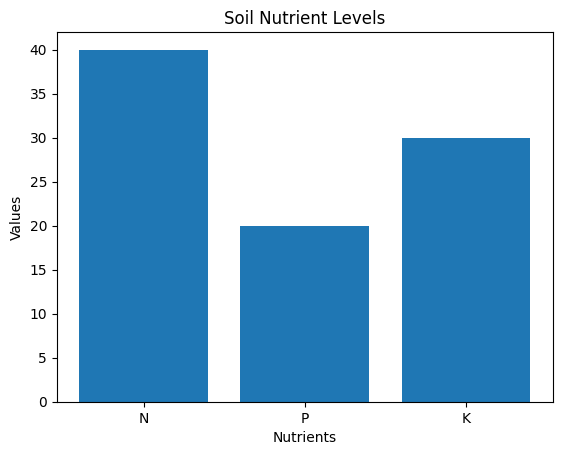

In [ ]:

import csv
import random
import matplotlib.pyplot as plt
from datetime import datetime

# Ideal ranges
IDEAL_N = (50, 100)
IDEAL_P = (30, 60)
IDEAL_K = (40, 80)
IDEAL_PH = (6.0, 7.5)

# Crop-specific requirements
CROP_NEEDS = {
    "rice": {"N": "high", "P": "medium", "K": "medium"},
    "wheat": {"N": "medium", "P": "medium", "K": "medium"},
    "tomato": {"N": "medium", "P": "low", "K": "high"},
    "potato": {"N": "medium", "P": "high", "K": "high"}
}


# Simulated weather function
def get_weather():
    weather_conditions = ["rainy", "sunny", "cloudy"]
    return random.choice(weather_conditions)


# Sensor input
def get_sensor_data():
    print("\nEnter Soil Sensor Values:")
    n = float(input("Nitrogen (N): "))
    p = float(input("Phosphorus (P): "))
    k = float(input("Potassium (K): "))
    ph = float(input("Soil pH: "))
    crop = input("Enter crop type (rice/wheat/tomato/potato): ").lower()
    return n, p, k, ph, crop


# Analysis logic
def analyze(n, p, k, ph, crop, weather):
    recs = []

    # NPK analysis
    if n < IDEAL_N[0]:
        recs.append("Add Nitrogen fertilizer (Urea)")
    elif n > IDEAL_N[1]:
        recs.append("Reduce Nitrogen application")

    if p < IDEAL_P[0]:
        recs.append("Add Phosphorus fertilizer (DAP)")
    elif p > IDEAL_P[1]:
        recs.append("Reduce Phosphorus")

    if k < IDEAL_K[0]:
        recs.append("Add Potassium fertilizer (MOP)")
    elif k > IDEAL_K[1]:
        recs.append("Reduce Potassium")

    # pH analysis
    if ph < IDEAL_PH[0]:
        recs.append("Soil acidic → Add Lime")
    elif ph > IDEAL_PH[1]:
        recs.append("Soil alkaline → Add Gypsum")

    # Crop-specific advice
    if crop in CROP_NEEDS:
        needs = CROP_NEEDS[crop]
        recs.append(f"{crop.capitalize()} prefers {needs['N']} N, {needs['P']} P, {needs['K']} K")

    # Weather-based logic
    if weather == "rainy":
        recs.append("Rain expected → Avoid fertilizer (leaching risk)")
    elif weather == "sunny":
        recs.append("Good weather → Suitable for fertilizer application")

    if not recs:
        recs.append("Soil is optimal")

    return recs


# Save data
def save_data(n, p, k, ph, crop):
    with open("soil_data.csv", "a", newline="") as file:
        writer = csv.writer(file)
        writer.writerow([datetime.now(), n, p, k, ph, crop])


# Visualization
def plot_data(n, p, k):
    nutrients = ['N', 'P', 'K']
    values = [n, p, k]

    plt.figure()
    plt.bar(nutrients, values)
    plt.title("Soil Nutrient Levels")
    plt.xlabel("Nutrients")
    plt.ylabel("Values")
    plt.show()


# Main function
def main():
    print("🌱 Smart Soil Fertilizer Monitoring System 🌱")

    n, p, k, ph, crop = get_sensor_data()
    weather = get_weather()

    print(f"\nWeather Condition: {weather}")

    recs = analyze(n, p, k, ph, crop, weather)

    print("\n--- Recommendations ---")
    for r in recs:
        print("-", r)

    save_data(n, p, k, ph, crop)

    plot_choice = input("\nShow graph? (yes/no): ")
    if plot_choice.lower() == "yes":
        plot_data(n, p, k)


if __name__ == "__main__":
    main()

In [ ]:
# Smart Soil Fertilizer Monitoring and Recommendation System (Improved)

# Ideal ranges
IDEAL = {
    "N": (50, 100),
    "P": (30, 60),
    "K": (40, 80),
    "pH": (6.0, 7.5),
    "moisture": (40, 70),   # %
    "temperature": (20, 35) # °C
}

# ---------------------------
# IoT Data Input Module
# ---------------------------
def get_sensor_data():
    print("Enter Soil Sensor Values:")

    data = {
        "N": float(input("Nitrogen (N): ")),
        "P": float(input("Phosphorus (P): ")),
        "K": float(input("Potassium (K): ")),
        "pH": float(input("Soil pH: ")),
        "moisture": float(input("Soil Moisture (%): ")),
        "temperature": float(input("Temperature (°C): ")),
        "soil_type": input("Soil Type (sandy/clay/loamy): ").lower(),
        "crop_type": input("Crop Type (rice/wheat/maize/etc): ").lower()
    }

    return data


# ---------------------------
# Smart Analysis Module
# ---------------------------
def analyze_soil(data):
    recommendations = []
    score = 0

    # Generic checker
    def check(param, value):
        low, high = IDEAL[param]

        if value < low:
            return "low"
        elif value > high:
            return "high"
        else:
            return "optimal"

    # NPK + pH analysis
    for nutrient in ["N", "P", "K"]:
        status = check(nutrient, data[nutrient])

        if status == "low":
            recommendations.append(f"Increase {nutrient} (Apply fertilizer)")
            score -= 1
        elif status == "high":
            recommendations.append(f"{nutrient} is high (Reduce usage)")
            score -= 1
        else:
            score += 1

    # pH
    ph_status = check("pH", data["pH"])
    if ph_status == "low":
        recommendations.append("Soil acidic → Add Lime")
    elif ph_status == "high":
        recommendations.append("Soil alkaline → Add Gypsum")

    # Moisture
    moisture_status = check("moisture", data["moisture"])
    if moisture_status == "low":
        recommendations.append("Low moisture → Irrigation needed")
    elif moisture_status == "high":
        recommendations.append("High moisture → Improve drainage")

    # Temperature
    temp_status = check("temperature", data["temperature"])
    if temp_status == "low":
        recommendations.append("Low temperature → Monitor crop growth")
    elif temp_status == "high":
        recommendations.append("High temperature → Increase watering")

    # Soil type logic (from paper concept)
    if data["soil_type"] == "sandy":
        recommendations.append("Sandy soil → Add organic matter (low nutrient retention)")
    elif data["soil_type"] == "clay":
        recommendations.append("Clay soil → Improve drainage")
    elif data["soil_type"] == "loamy":
        recommendations.append("Loamy soil → Ideal soil type")

    # Crop-based recommendation (basic AI idea)
    crop = data["crop_type"]
    if crop in ["rice", "wheat"]:
        recommendations.append("High nutrient crop → Ensure sufficient NPK")
    elif crop in ["pulses"]:
        recommendations.append("Legumes → Less Nitrogen needed")

    # Final decision
    if score >= 3:
        recommendations.append("Overall Soil Status: GOOD")
    else:
        recommendations.append("Overall Soil Status: NEEDS IMPROVEMENT")

    return recommendations


# ---------------------------
# Output Module
# ---------------------------
def display_results(data, recs):
    print("\n--- Soil Analysis Report ---")

    for key, value in data.items():
        print(f"{key.upper()}: {value}")

    print("\n--- Recommendations ---")
    for r in recs:
        print(f"- {r}")


# ---------------------------
# Main Function
# ---------------------------
def main():
    data = get_sensor_data()
    recs = analyze_soil(data)
    display_results(data, recs)


if __name__ == "__main__":
    main()

Enter Soil Sensor Values:
Nitrogen (N): 30
Phosphorus (P): 3
Potassium (K): 30
Soil pH: 5
Soil Moisture (%): 60
Temperature (°C): 24
Soil Type (sandy/clay/loamy): Loamy
Crop Type (rice/wheat/maize/etc): Maize

--- Soil Analysis Report ---
N: 30.0
P: 3.0
K: 30.0
PH: 5.0
MOISTURE: 60.0
TEMPERATURE: 24.0
SOIL_TYPE: loamy
CROP_TYPE: maize

--- Recommendations ---
- Increase N (Apply fertilizer)
- Increase P (Apply fertilizer)
- Increase K (Apply fertilizer)
- Soil acidic → Add Lime
- Loamy soil → Ideal soil type
- Overall Soil Status: NEEDS IMPROVEMENT


In [ ]:
# Smart Fertilizer Recommendation System (Using Real Dataset)

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# -------------------------------
# Step 1: Load Dataset
# -------------------------------

df = pd.read_csv("fertilizer_data.csv") # Corrected filename

# Fix column names (remove spaces)
df.columns = df.columns.str.strip()

# -------------------------------
# Step 2: Encode Categorical Data
# -------------------------------

le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fertilizer = LabelEncoder()

df['Soil_Type'] = le_soil.fit_transform(df['Soil_Type'])
df['Crop_Type'] = le_crop.fit_transform(df['Crop_Type'])
df['Fertilizer'] = le_fertilizer.fit_transform(df['Fertilizer'])

# -------------------------------
# Step 3: Define Features & Target
# -------------------------------

X = df[['N', 'P', 'K', 'temperature', 'moisture',
        'Soil_Type', 'Crop_Type']]

y = df['Fertilizer']

# -------------------------------
# Step 4: Train-Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# -------------------------------
# Step 5: Train Model
# -------------------------------

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# Step 6: Evaluate Model
# -------------------------------

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy * 100, "%")

# -------------------------------
# Step 7: Prediction (User Input)
# -------------------------------

# Example input (you can change in viva)
sample_data = [[30, 60, 40,   # N, P, K
                25, 60,         # temperature, moisture
                1, 2]]  # Soil Type, Crop Type (encoded values)

# Convert sample to DataFrame with correct column names to avoid UserWarning
sample_df = pd.DataFrame(sample_data, columns=X.columns)

prediction = model.predict(sample_df)

# Convert back to fertilizer name
result = le_fertilizer.inverse_transform(prediction)

print("Recommended Fertilizer:", result[0])

Model Accuracy: 0.0 %
Recommended Fertilizer: Urea


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# -------------------------------
# Step 1: Load Dataset
# -------------------------------
df = pd.read_csv("fertilizer_data.csv")

# Clean column names (important fix)
df.columns = df.columns.str.strip().str.replace(" ", "_")

# -------------------------------
# Step 2: Handle Missing Values
# -------------------------------
df = df.dropna()

# -------------------------------
# Step 3: Encode Categorical Data
# -------------------------------
le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fertilizer = LabelEncoder()

df['Soil_Type'] = le_soil.fit_transform(df['Soil_Type'])
df['Crop_Type'] = le_crop.fit_transform(df['Crop_Type'])
df['Fertilizer'] = le_fertilizer.fit_transform(df['Fertilizer'])

# -------------------------------
# Step 4: Define Features & Target
# -------------------------------
X = df[['N', 'P', 'K', 'temperature', 'moisture', 'Soil_Type', 'Crop_Type']]
y = df['Fertilizer']

# -------------------------------
# Step 5: Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Step 6: Train Model
# -------------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# Step 7: Evaluate Model
# -------------------------------
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

# -------------------------------
# Step 8: Prediction (Safe Input)
# -------------------------------

# Use REAL encoded values instead of guessing
soil_input = "Clay"      # change based on your dataset
crop_input = "Wheat"     # change based on your dataset

# Convert to encoded values safely
soil_encoded = le_soil.transform([soil_input])[0]
crop_encoded = le_crop.transform([crop_input])[0]

# Example input
sample_data = [[30, 60, 40, 25, 60, soil_encoded, crop_encoded]]

# Convert to DataFrame (prevents warnings/errors)
sample_df = pd.DataFrame(sample_data, columns=X.columns)

# Prediction
prediction = model.predict(sample_df)

# Convert back to fertilizer name
result = le_fertilizer.inverse_transform(prediction)

print("Recommended Fertilizer:", result[0])

Model Accuracy: 0.0 %
Recommended Fertilizer: Urea


In [ ]:
# Smart Fertilizer Recommendation System (Using Real Dataset)

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# -------------------------------
# Step 1: Load Dataset
# -------------------------------

df = pd.read_csv("fertilizer_data.csv") # Corrected filename

# Fix column names (remove spaces)
df.columns = df.columns.str.strip()

# -------------------------------
# Step 2: Encode Categorical Data
# -------------------------------

le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fertilizer = LabelEncoder()

df['Soil_Type'] = le_soil.fit_transform(df['Soil_Type'])
df['Crop_Type'] = le_crop.fit_transform(df['Crop_Type'])
df['Fertilizer'] = le_fertilizer.fit_transform(df['Fertilizer'])

# -------------------------------
# Step 3: Define Features & Target
# -------------------------------

X = df[['N', 'P', 'K', 'temperature', 'moisture',
        'Soil_Type', 'Crop_Type']]

y = df['Fertilizer']

# -------------------------------
# Step 4: Train-Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# -------------------------------
# Step 5: Train Model
# -------------------------------

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# Step 6: Evaluate Model
# -------------------------------

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy * 100, "%")

# -------------------------------
# Step 7: Prediction (User Input)
# -------------------------------

# Example input (you can change in viva)
sample_data = [[30, 60, 40,   # N, P, K
                25, 60,         # temperature, moisture
                1, 2]]  # Soil Type, Crop Type (encoded values)

# Convert sample to DataFrame with correct column names to avoid UserWarning
sample_df = pd.DataFrame(sample_data, columns=X.columns)

prediction = model.predict(sample_df)

# Convert back to fertilizer name
result = le_fertilizer.inverse_transform(prediction)

print("Recommended Fertilizer:", result[0])

Model Accuracy: 0.0 %
Recommended Fertilizer: Urea
